In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

csv_path = Path(r"C:\Users\user\Desktop\div\data\files\housing.csv")
df = pd.read_csv(csv_path)
df.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


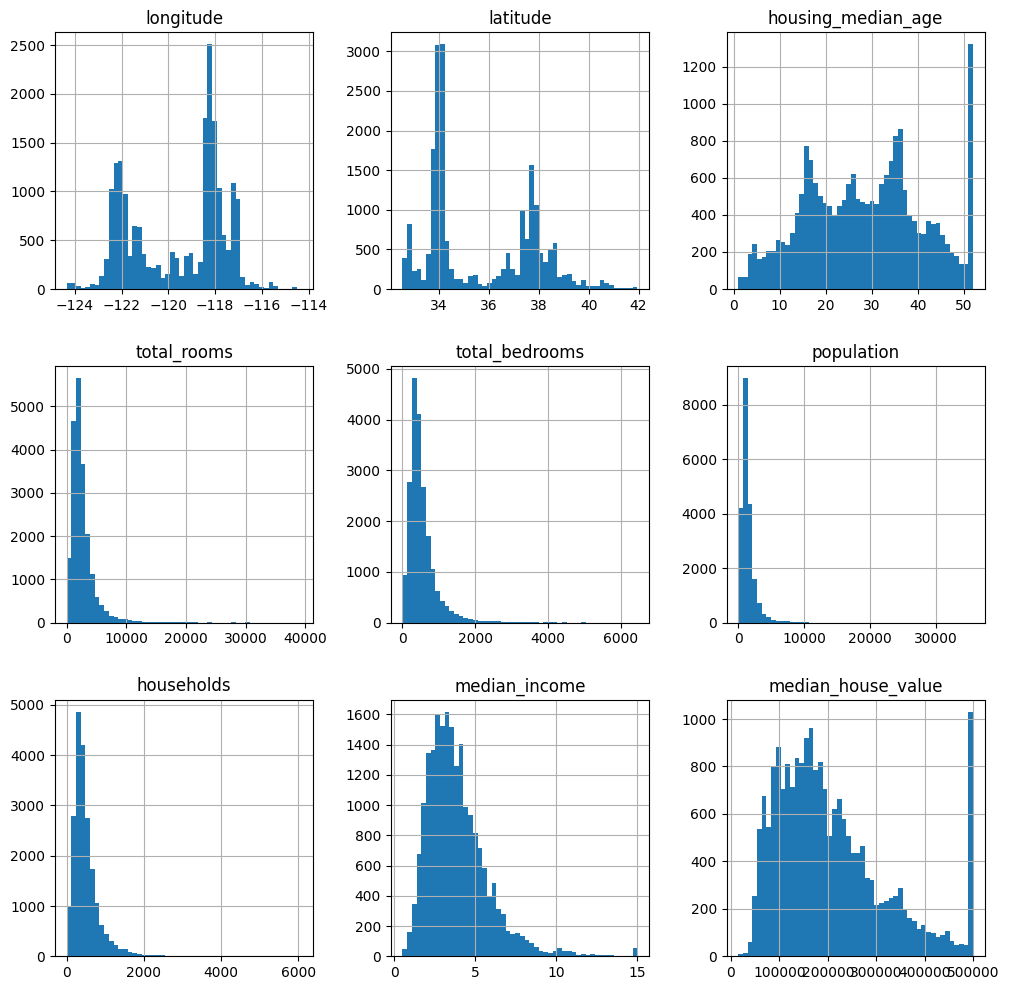

In [4]:
df.hist(bins=50, figsize=(12, 12))
plt.show()

In [11]:
outlier1 = df['housing_median_age'] == df['housing_median_age'].max()
outlier2 = df['median_house_value'] == df['median_house_value'].max()

df = df.loc[~outlier1 & ~outlier2, :]
df.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


In [15]:
y = df['median_house_value']
X = df.drop('median_house_value', axis='columns')

In [24]:
from sklearn.model_selection import train_test_split

X['income_cat'] = pd.cut(
    X['median_income'], 
    bins=[0,2,4,6,8,np.inf],
    labels=[1,2,3,4,5],
)

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.15,
    stratify=df['income_cat']
    )

X_train.drop('income_cat', axis='columns', inplace=True)
X_test.drop('income_cat', axis='columns', inplace=True)
X_train.shape , X_test.shape

((15786, 9), (2786, 9))

In [42]:
import plotly.express as px

px.scatter_map(
    X_train,
    lat='latitude', 
    lon='longitude', 
    zoom=4, 
    size='population'
    )

In [74]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans
km = KMeans(n_clusters=10)
km.fit(X_train[['longitude', 'latitude']])
# km.labels_

rbf_kernel(X_train[['longitude', 'latitude']], km.cluster_centers_, gamma=1).round(3)


array([[0.   , 0.999, 0.   , ..., 0.   , 0.429, 0.001],
       [0.   , 0.73 , 0.   , ..., 0.   , 0.121, 0.01 ],
       [0.358, 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
       ...,
       [0.176, 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.302, ..., 0.732, 0.003, 0.   ],
       [0.18 , 0.   , 0.064, ..., 0.   , 0.   , 0.   ]], shape=(15786, 10))

In [88]:
u = X_train.loc[0, ['longitude', 'latitude']].to_numpy()
v = km.cluster_centers_[1, :]

gamma = 1

rbf_value = 1 / np.exp(gamma * (np.linalg.norm(u-v))**2)
rbf_value.round(2)

np.float64(0.99)

In [ ]:
class Heyvan:
	def __init__(self):
		pass

class It(Heyvan):
	def __init__(self, itin_adi):
		self.ad = itin_adi

	def huru(self):
		return 'hav hav'
    
i1 = It('toplash')
i1.huru()

'hav hav'

In [68]:
from sklearn.base import TransformerMixin, BaseEstimator

class ClusterSim(BaseEstimator, TransformerMixin):
	def __init__(self, n_clusters):
		self.n_clusters = n_clusters
		self.km = None

	def fit(self, X):
		self.km = KMeans(n_clusters=self.n_clusters)
		self.km.fit(X)
		return self
    
	def transform(self, *args):
		return self.km.labels_[:, np.newaxis]
	
	def get_feature_names_out(self, *args):
		return ['cluster']

cls = ClusterSim(10)
cls.fit(X[['latitude', 'longitude']])
cls.transform(X[['latitude', 'longitude']])

array([[1],
       [1],
       [1],
       ...,
       [8],
       [8],
       [8]], shape=(18572, 1), dtype=int32)

In [69]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_cols = ['longitude', 'latitude', 'housing_median_age']
log_cols = ['total_rooms','total_bedrooms', 'population', 'households', 'median_income',]
cat_cols = ['ocean_proximity']

num_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy="median")),
    ('scl', StandardScaler())
])
geo_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy="median")),
    ('cluster', ClusterSim(10))
])
log_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy="median")),
    ('log', FunctionTransformer(func=np.log, inverse_func=np.exp, feature_names_out='one-to-one')),
    ('scl', StandardScaler())
])
rat_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy="median")),
    ('rat', FunctionTransformer(
        func=lambda arr: arr[:, [0]] / arr[:, [1]],  
        feature_names_out=lambda *args: ['ratio'],
        )),
    ('scl', StandardScaler())
])
cat_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy="most_frequent")),
    ('scl', OneHotEncoder())
])

preprocessing = ColumnTransformer([
    ("NUM", num_pipeline, num_cols),
    ("LOG", log_pipeline, log_cols),
    ("CAT", cat_pipeline, cat_cols),
    ("GEO", geo_pipeline, ['latitude', 'longitude']),
    ("RAT_tb/tr", rat_pipeline, ['total_bedrooms', 'total_rooms',]),
    ("RAT_h/tr", rat_pipeline, ['households', 'total_rooms',]),
    ("RAT_p/tr", rat_pipeline, ['population', 'total_rooms',]),
])

X_train_arr = preprocessing.fit_transform(X_train)
X_train_tr = pd.DataFrame(X_train_arr, columns=preprocessing.get_feature_names_out())
X_train_tr.head()

,NUM__longitude,NUM__latitude,NUM__housing_median_age,LOG__total_rooms,LOG__total_bedrooms,LOG__population,LOG__households,LOG__median_income,CAT__ocean_proximity_<1H OCEAN,CAT__ocean_proximity_INLAND,CAT__ocean_proximity_ISLAND,CAT__ocean_proximity_NEAR BAY,CAT__ocean_proximity_NEAR OCEAN,GEO__cluster,RAT_tb/tr__ratio,RAT_h/tr__ratio,RAT_p/tr__ratio
0,-1.439603,1.101274,-1.053029,1.531340,1.913567,1.469763,1.864794,-0.971012,0.0,0.0,0.0,1.0,0.0,8.0,0.818321,0.731046,-0.034287
1,-1.621347,1.287430,-1.402712,1.384241,0.980819,1.066355,1.068025,0.513175,1.0,0.0,0.0,0.0,0.0,8.0,-1.043431,-0.917400,-0.061283
2,1.140160,-1.165178,-1.752394,1.263729,0.943902,0.750530,0.886357,1.438210,0.0,0.0,0.0,0.0,1.0,0.0,-0.883399,-1.031692,-0.078729
3,-0.217875,0.547459,-0.790767,-0.516607,-0.805699,-0.692629,-0.778371,0.163795,0.0,1.0,0.0,0.0,0.0,4.0,-0.716912,-0.712904,-0.043893
4,-1.343682,1.254853,-0.878188,-0.336546,-0.828782,-0.690681,-0.814867,1.526903,0.0,0.0,0.0,1.0,0.0,8.0,-1.106610,-1.151165,-0.062403
